# **Pola Penyewaan Sepeda per Jam di Seoul (2017–2018)**
#### **Kelompok 12**

| Nama | NRP |
| --- | --- |
| Musthofa Kamaluddin | 5027261075 |
| Nail Athallah Ramadhan | 5027261093 |
| Akilah Tiara Hepi | 5027261124 |

**Topik:** Smart City - Bike Sharing


**Latar Belakang:**  
Sistem bike sharing atau sepeda sewa publik menjadi salah satu solusi transportasi kota yang semakin populer karena murah, ramah lingkungan, dan membantu mengurangi kemacetan pada jarak tempuh pendek. Namun, penyedia layanan sering menghadapi masalah ketersediaan sepeda: pada jam-jam tertentu sepeda bisa kosong di satu stasiun, sementara di waktu lain justru menumpuk tidak terpakai. Dataset Seoul Bike Sharing Demand mencatat jumlah sepeda yang disewa setiap jam selama satu tahun (Desember 2017–November 2018) beserta kondisi cuaca (suhu, kelembapan, curah hujan, dll.), musim, dan status hari libur pada saat itu. Data ini menarik untuk dianalisis karena memungkinkan kita melihat pola penyewaan sepeda berdasarkan waktu dan kondisi cuaca, yang bisa menjadi dasar bagi pengelola untuk memprediksi kebutuhan sepeda dan mendistribusikannya secara lebih efisien di kota.  

**Pertanyaan:**
1. Berapa rata-rata dan seberapa besar variasi jumlah sepeda yang disewa per jam sepanjang tahun tersebut?
2. Bagaimana perbedaan pola jumlah penyewaan sepeda antara empat musim (Winter, Spring, Summer, Autumn)?
3. Apakah ada kaitan antara suhu udara dan jumlah sepeda yang disewa, dan bagaimana bentuk hubungannya?

In [1]:
import pandas as pd

df = pd.read_csv("data/SeoulBikeData.csv", encoding="latin-1")
print(df.shape)   # (jumlah baris, jumlah kolom)
df.head()

(8760, 14)


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


**Satu baris pada data ini mewakili:** satu jam pengamatan pada satu tanggal tertentu di Seoul. Terdiri dari kombinasi (Date, Hour) beserta jumlah sepeda yang disewa pada jam tersebut dan kondisi cuaca pada saat itu.

**Sumber data:** UCI Machine Learning Repository - *Seoul Bike Sharing Demand*  
Link: https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand

**Lisensi:** Creative Commons Attribution 4.0 International (CC BY 4.0)

**Siapa yang mengumpulkan & kapan:** Data dikumpulkan oleh Seoul Metropolitan Government dan didonasikan ke UCI Repository pada 29 Februari 2020. Data mencakup periode 1 Desember 2017 - 30 November 2018, direkam per jam.

**Jumlah baris dan kolom:** 8.760 baris (24 jam x 365 hari) dan 14 kolom.

### **Kamus Data**

| Kolom | Arti | Jenis Variabel | Skala | Satuan | Contoh |
|---|---|---|---|---|---|
| Date | Tanggal pengamatan | Kualitatif | - | dd/mm/yyyy | 01/12/2017 |
| Rented Bike Count | Jumlah sepeda yang disewa pada jam tersebut | Kuantitatif diskrit | Rasio | unit | 254 |
| Hour | Jam dalam sehari (0–23) | Kuantitatif diskrit | Interval | jam | 0 |
| Temperature(°C) | Suhu udara | Kuantitatif kontinu | Interval | °C | -5.2 |
| Humidity(%) | Kelembapan udara | Kuantitatif diskrit | Rasio | % | 37 |
| Wind speed (m/s) | Kecepatan angin | Kuantitatif kontinu | Rasio | m/s | 2.2 |
| Visibility (10m) | Jarak pandang | Kuantitatif diskrit | Rasio | 10m | 2000 |
| Dew point temperature(°C) | Suhu titik embun | Kuantitatif kontinu | Interval | °C | -17.6 |
| Solar Radiation (MJ/m2) | Intensitas radiasi matahari | Kuantitatif kontinu | Rasio | MJ/m² | 0.0 |
| Rainfall(mm) | Curah hujan | Kuantitatif kontinu | Rasio | mm | 0.0 |
| Snowfall (cm) | Curah salju | Kuantitatif kontinu | Rasio | cm | 0.0 |
| Seasons | Musim saat pengamatan | Kualitatif | Nominal | - | Winter |
| Holiday | Status hari libur | Kualitatif | Nominal | - | No Holiday |
| Functioning Day | Apakah sistem bike sharing beroperasi normal pada jam itu | Kualitatif | Nominal | - | Yes |

## **Pemeriksaan Kualitas Data**

In [2]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y') #kita ubah tipe data Date dari str to datetime64 biar enak aja hehe
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8760 non-null   datetime64[us]
 1   Rented Bike Count          8760 non-null   int64         
 2   Hour                       8760 non-null   int64         
 3   Temperature(°C)            8760 non-null   float64       
 4   Humidity(%)                8760 non-null   int64         
 5   Wind speed (m/s)           8760 non-null   float64       
 6   Visibility (10m)           8760 non-null   int64         
 7   Dew point temperature(°C)  8760 non-null   float64       
 8   Solar Radiation (MJ/m2)    8760 non-null   float64       
 9   Rainfall(mm)               8760 non-null   float64       
 10  Snowfall (cm)              8760 non-null   float64       
 11  Seasons                    8760 non-null   str           
 12  Holiday          

np.int64(0)

**Temuan pemeriksaan kualitas data:**  
- Data kosong: Tidak ada. Dari df.info(), semua 14 kolom menunjukkan "8760 non-null", dan dari df.isna().sum() seluruh kolom bernilai 0. dataset ini  sudah bersih dari data kosong sejak dari sumbernya.  
- Data duplikat: Tidak ada. Hasil df.duplicated().sum() menunjukkan 0, artinya tidak ada baris yang identik persis dengan baris lain.  
- Tipe data: Ada satu kolom yang tipenya kurang tepat: Date masih terbaca sebagai teks (str), padahal seharusnya bertipe tanggal (datetime) agar bisa diolah secara kronologis. Sedangkan untuk kolom-kolom numerik lain sudah sesuai jenisnya.  
- Nilai yang tidak masuk akal: Tidak ditemukan nilai yang aneh secara sepintas.  

**Keputusan pembersihan data:**  
Karena tidak ada data kosong maupun duplikat, maka tidak perlu ada baris yang dihapus. Satu-satunya perbaikan yang dilakukan adalah mengonversi kolom Date dari teks menjadi tipe datetime agar data lebih mudah diolah jika nanti diperlukan analisis berdasarkan waktu.

## **Statistik Deskriptif Variabel Numerik**

In [3]:
kolom_numerik = ["Rented Bike Count", "Temperature(\u00b0C)", "Humidity(%)"]

ringkasan = pd.DataFrame({
    "mean": df[kolom_numerik].mean(),
    "median": df[kolom_numerik].median(),
    "modus": df[kolom_numerik].mode().iloc[0],
    "min": df[kolom_numerik].min(),
    "max": df[kolom_numerik].max(),
    "range": df[kolom_numerik].max() - df[kolom_numerik].min(),
    "varians": df[kolom_numerik].var(),
    "std": df[kolom_numerik].std(),
    "Q1": df[kolom_numerik].quantile(0.25),
    "Q3": df[kolom_numerik].quantile(0.75),
})
ringkasan["IQR"] = ringkasan["Q3"] - ringkasan["Q1"]
ringkasan


,mean,median,modus,min,max,range,varians,std,Q1,Q3,IQR
Rented Bike Count,704.602055,504.5,0.0,0.0,3556.0,3556.0,416021.733390,644.997468,191.0,1065.25,874.25
Temperature(°C),12.882922,13.7,19.1,-17.8,39.4,57.2,142.678850,11.944825,3.5,22.50,19.00
Humidity(%),58.226256,57.0,53.0,0.0,98.0,98.0,414.627875,20.362413,42.0,74.00,32.00


### Varians / Simpangan Baku 
(kasih kami nilai plus bu mwehehe)

In [4]:
sampel_10 = df["Rented Bike Count"].head(10)
n = len(sampel_10)
rata2 = sampel_10.sum() / n
varians_manual = ((sampel_10 - rata2) ** 2).sum() / (n - 1)
std_manual = varians_manual ** 0.5

print("Rata-rata manual :", rata2)
print("Varians manual   :", varians_manual)
print("Std manual       :", std_manual)
print("Varians pandas   :", sampel_10.var())
print("Std pandas       :", sampel_10.std())

Rata-rata manual : 297.7
Varians manual   : 69633.56666666667
Std manual       : 263.88172855782693
Varians pandas   : 69633.56666666667
Std pandas       : 263.88172855782693


## **Ringkasan Variabel Kategorik**

In [5]:
df["Seasons"].value_counts()
df["Seasons"].value_counts(normalize=True) * 100

Seasons
Spring    25.205479
Summer    25.205479
Autumn    24.931507
Winter    24.657534
Name: proportion, dtype: float64

## **Visualisasi Data**

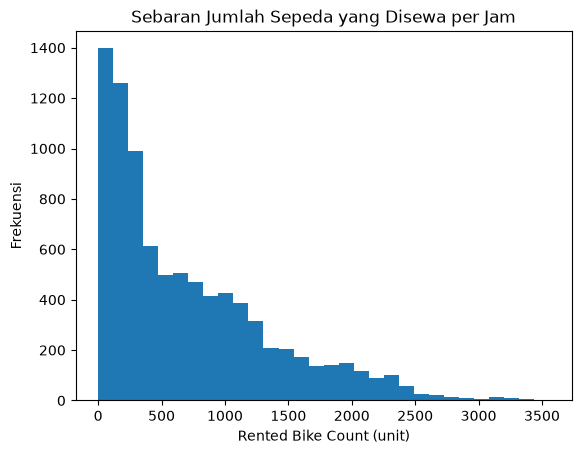

In [6]:
import matplotlib.pyplot as plt

plt.hist(df["Rented Bike Count"], bins=30)
plt.title("Sebaran Jumlah Sepeda yang Disewa per Jam")
plt.xlabel("Rented Bike Count (unit)")
plt.ylabel("Frekuensi")
plt.show()

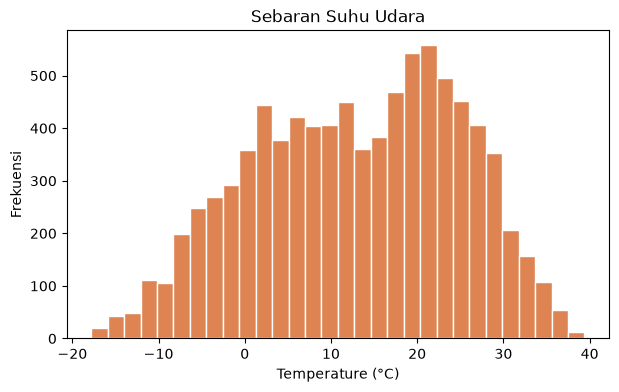

In [7]:
plt.figure(figsize=(7,4))
plt.hist(df["Temperature(\u00b0C)"], bins=30, color="#DD8452", edgecolor="white")
plt.title("Sebaran Suhu Udara")
plt.xlabel("Temperature (\u00b0C)")
plt.ylabel("Frekuensi")
plt.show()

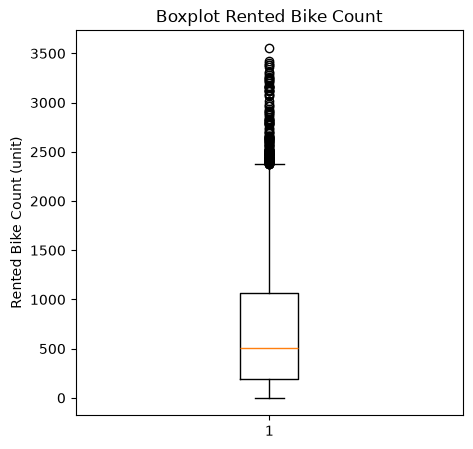

Batas bawah: -1120.375 | Batas atas: 2376.625
Jumlah pencilan: 158


In [8]:
plt.figure(figsize=(5,5))
plt.boxplot(df["Rented Bike Count"], orientation="vertical")
plt.title("Boxplot Rented Bike Count")
plt.ylabel("Rented Bike Count (unit)")
plt.show()

Q1 = df["Rented Bike Count"].quantile(0.25)
Q3 = df["Rented Bike Count"].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR
pencilan = df[(df["Rented Bike Count"] < batas_bawah) | (df["Rented Bike Count"] > batas_atas)]
print("Batas bawah:", batas_bawah, "| Batas atas:", batas_atas)
print("Jumlah pencilan:", len(pencilan))

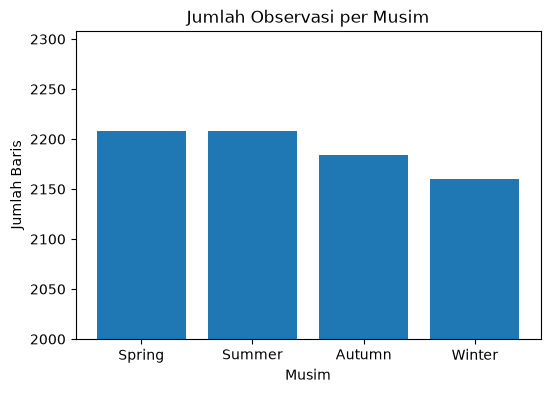

In [9]:
jumlah_per_musim = df["Seasons"].value_counts()
plt.figure(figsize=(6,4))
plt.bar(jumlah_per_musim.index, jumlah_per_musim.values)
plt.title("Jumlah Observasi per Musim")
plt.xlabel("Musim")
plt.ylabel("Jumlah Baris")

plt.ylim(2000, jumlah_per_musim.max() + 100)

plt.show()

In [14]:
df.groupby("Seasons")["Rented Bike Count"].median().sort_values(ascending=False)

Seasons
Summer    905.5
Autumn    763.5
Spring    583.0
Winter    203.0
Name: Rented Bike Count, dtype: float64

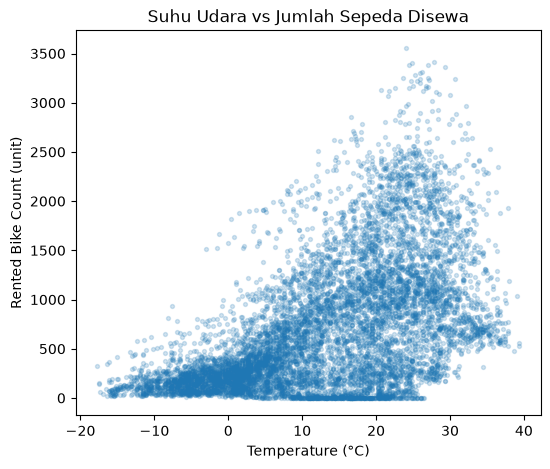

In [11]:
plt.figure(figsize=(6,5))
plt.scatter(df["Temperature(\u00b0C)"], df["Rented Bike Count"], alpha=0.2, s=8)
plt.title("Suhu Udara vs Jumlah Sepeda Disewa")
plt.xlabel("Temperature (\u00b0C)")
plt.ylabel("Rented Bike Count (unit)")
plt.show()

## Kesimpulan

**Pertanyaan:**
1. Berapa rata-rata dan seberapa besar variasi jumlah sepeda yang disewa per jam sepanjang tahun tersebut?
2. Bagaimana perbedaan pola jumlah penyewaan sepeda antara empat musim (Winter, Spring, Summer, Autumn)?
3. Apakah ada kaitan antara suhu udara dan jumlah sepeda yang disewa, dan bagaimana bentuk hubungannya?

**Jawaban:**  
1. Rata-rata jumlah sepeda yang disewa adalah 704,6 sepeda per jam, dengan standar deviasi sebesar 645,0 dan varians sebesar 416.021,7. Nilai penyewaan berada pada rentang 0 hingga 3.556 sepeda per jam.
2. Terdapat perbedaan jumlah penyewaan antar musim. Berdasarkan median, Summer memiliki jumlah penyewaan tertinggi sebesar 905,5 sepeda, diikuti oleh Autumn sebesar 763,5, Spring sebesar 583, dan Winter sebesar 203 sepeda.
3. Berdasarkan scatter plot, terlihat adanya kecenderungan hubungan positif antara suhu udara dan jumlah sepeda yang disewa. Ketika suhu meningkat, jumlah penyewaan secara umum juga cenderung meningkat. Namun, titik-titik data cukup menyebar sehingga suhu bukan satu-satunya faktor yang menentukan jumlah penyewaan.

## Temuan Menarik
- Jumlah penyewaan sepeda memiliki variasi yang cukup besar, terlihat dari standar deviasi 645,0, yang hampir mendekati nilai rata-ratanya.
- Perbedaan antar musim cukup terlihat. Median penyewaan pada Summer (905,5) lebih dari empat kali median pada Winter (203).
- Data memiliki 8.760 observasi dan tidak ditemukan data kosong maupun baris duplikat, sehingga dataset relatif lengkap untuk dilakukan eksplorasi.
- Distribusi jumlah penyewaan menunjukkan adanya nilai yang cukup tinggi dibandingkan sebagian besar data, sehingga terdapat beberapa observasi yang dapat dianggap sebagai pencilan berdasarkan metode IQR.


## Keterbatasan Data
- Analisis hanya menggunakan data selama 1 tahun, yaitu Desember 2017 sampai November 2018, sehingga belum dapat menggambarkan perubahan pola penyewaan dalam jangka waktu beberapa tahun.
- Analisis yang dilakukan masih bersifat eksploratif dan belum mengukur hubungan antarvariabel secara statistik secara mendalam.
- Jumlah penyewaan dapat dipengaruhi oleh banyak faktor lain seperti jam, hari kerja/libur, kelembapan, hujan, salju, dan kondisi operasional, sehingga hubungan suhu dengan jumlah penyewaan tidak dapat dianggap sebagai hubungan sebab-akibat.
- Data berasal dari sistem bike sharing di Seoul, sehingga hasil analisis belum tentu dapat langsung diterapkan pada kota lain dengan kondisi cuaca, transportasi, dan kebiasaan masyarakat yang berbeda.

## Ide Pertanyaan Lanjutan
1. Pada jam berapa jumlah penyewaan sepeda paling tinggi dan paling rendah dalam satu hari?
2. Apakah jumlah penyewaan berbeda secara signifikan antara hari libur dan hari biasa?
3. Seberapa besar pengaruh kelembapan, curah hujan, salju, dan kecepatan angin terhadap jumlah sepeda yang disewa?
4. Apakah pola penyewaan berbeda antara hari kerja dan akhir pekan pada setiap musim?
5. Dapatkah jumlah penyewaan sepeda diprediksi berdasarkan kondisi cuaca dan waktu?

## Referensi dan catatan penggunaan AI

| Alat                            | Dipakai Untuk                                                                                                       | Yang Kami Pelajari                                                                             |
| ------------------------------- | ------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------- |
| UCI Machine Learning Repository | Mengambil dataset *Seoul Bike Sharing Demand* dan memahami informasi dataset | Memahami sumber, struktur, variabel, periode pengumpulan, dan karakteristik dataset |
| Claude | Debugging kode, analisis error, dan perbaikan error | Memahami perbedaan rumus populasi dan sampel pada statistik deskriptif (varians & std) serta mengimplementasikannya secara manual di Python tanpa library bawaan. |
| Gemini | Membantu memahami penulisan Markdown dan perbaikan error | Menguasai sintaksis Markdown untuk dokumentasi yang rapi (seperti pembuatan tabel dan format teks), serta mempercepat identifikasi sintaksis error pada kode. |